In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [ ]:
import seaborn as sns

In [ ]:
df = pd.read_csv('../data/Mall_Customers.csv')

In [ ]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [ ]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [ ]:
df.shape

(200, 5)

In [ ]:
df["Gender"].unique()

<StringArray>
['Male', 'Female']
Length: 2, dtype: str

In [ ]:
#  using sklearn to OneHotEncode
from sklearn.preprocessing import OneHotEncoder

# OneHotEncoder
ohe = OneHotEncoder(drop='first', sparse_output=False)
gender_encoded = ohe.fit_transform(df[['Gender']])

# Create DataFrame with encoded columns
feature_names = ohe.get_feature_names_out(['Gender'])
encoded_df = pd.DataFrame(gender_encoded, columns=feature_names, index=df.index)

# Drop original categorical columns and concatenate
df = df.drop('Gender', axis=1)
df = pd.concat([df, encoded_df], axis=1)


In [ ]:

df.head()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Gender_Male
0,1,19,15,39,1.0
1,2,21,15,81,1.0
2,3,20,16,6,0.0
3,4,23,16,77,0.0
4,5,31,17,40,0.0


In [ ]:
df =df.drop(columns=["CustomerID"])

In [ ]:
df.head()

,Age,Annual Income (k$),Spending Score (1-100),Gender_Male
0,19,15,39,1.0
1,21,15,81,1.0
2,20,16,6,0.0
3,23,16,77,0.0
4,31,17,40,0.0


In [ ]:
# 3. We Scale the data 

X= df

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler() # Creating the object of the standard sclare class
X_scaled = scaler.fit_transform(df) # fit is to get the mean

In [ ]:
X_scaled

array([[-1.42456879, -1.73899919, -0.43480148,  1.12815215],
       [-1.28103541, -1.73899919,  1.19570407,  1.12815215],
       [-1.3528021 , -1.70082976, -1.71591298, -0.88640526],
       [-1.13750203, -1.70082976,  1.04041783, -0.88640526],
       [-0.56336851, -1.66266033, -0.39597992, -0.88640526],
       [-1.20926872, -1.66266033,  1.00159627, -0.88640526],
       [-0.27630176, -1.62449091, -1.71591298, -0.88640526],
       [-1.13750203, -1.62449091,  1.70038436, -0.88640526],
       [ 1.80493225, -1.58632148, -1.83237767,  1.12815215],
       [-0.6351352 , -1.58632148,  0.84631002, -0.88640526],
       [ 2.02023231, -1.58632148, -1.4053405 ,  1.12815215],
       [-0.27630176, -1.58632148,  1.89449216, -0.88640526],
       [ 1.37433211, -1.54815205, -1.36651894, -0.88640526],
       [-1.06573534, -1.54815205,  1.04041783, -0.88640526],
       [-0.13276838, -1.54815205, -1.44416206,  1.12815215],
       [-1.20926872, -1.54815205,  1.11806095,  1.12815215],
       [-0.27630176, -1.

In [ ]:
# 4. The Eblow Method - here we look for the errors or the inertia
from sklearn.cluster import KMeans
inertias = []

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=9)
    km.fit(X_scaled)
    inertias.append(km.inertia_) # is the within cluster sum squared (WCSS)

In [ ]:
inertias

[588.8026767824934,
 476.7875544135159,
 388.7178614053845,
 331.3098837641086,
 277.38974019851906,
 236.2049470708688,
 199.75046112065573,
 174.23547730691476,
 152.0298342977569]

Text(0.5, 1.0, 'Elbow curve')

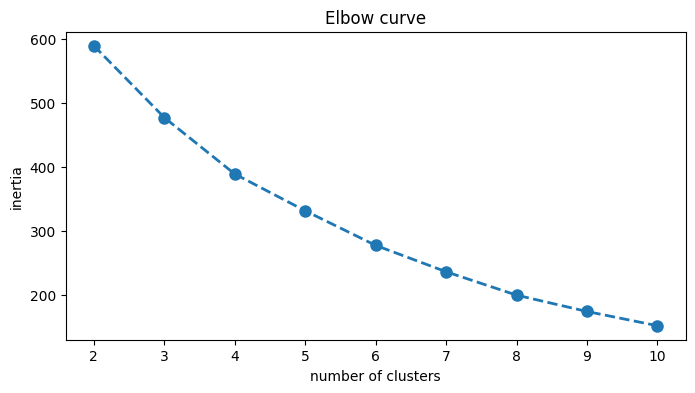

In [ ]:
#5. Plotting the eblow Curve

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(range(2, 11), inertias, 'o--', linewidth=2, markersize=8)
plt.xlabel('number of clusters')
plt.ylabel('inertia')
plt.title('Elbow curve')


In [ ]:
#step 6.  Best k =4, train/fit using 4 clusters
km_final= KMeans(n_clusters=2, random_state=42, n_init=9)
df['cluster'] = km_final.fit_predict(X_scaled) # km_final_fit(X_scaled) + km_final.predict(X_scaled)
df


,Age,Annual Income (k$),Spending Score (1-100),Gender_Male,cluster
0,19,15,39,1.0,0
1,21,15,81,1.0,0
2,20,16,6,0.0,1
3,23,16,77,0.0,0
4,31,17,40,0.0,0
...,...,...,...,...,...
195,35,120,79,0.0,0
196,45,126,28,0.0,1
197,32,126,74,1.0,0
198,32,137,18,1.0,1


In [ ]:
#step 7.  Create a profile for each cluster
profile = df.groupby('cluster').agg({
    'Age':'mean',
    'Annual Income (k$)':'mean',
    'Spending Score (1-100)':'mean',
    'Gender_Male':'mean',
    'cluster':'count'
}).rename(columns={'cluster':'count'})

print(profile)

               Age  Annual Income (k$)  Spending Score (1-100)  Gender_Male  \
cluster                                                                       
0        28.360825           60.628866               69.329897     0.412371   
1        48.728155           60.495146               32.184466     0.466019   

         count  
cluster         
0           97  
1          103  


In [ ]:
df.head()

,Age,Annual Income (k$),Spending Score (1-100),Gender_Male,cluster
0,19,15,39,1.0,0
1,21,15,81,1.0,0
2,20,16,6,0.0,1
3,23,16,77,0.0,0
4,31,17,40,0.0,0


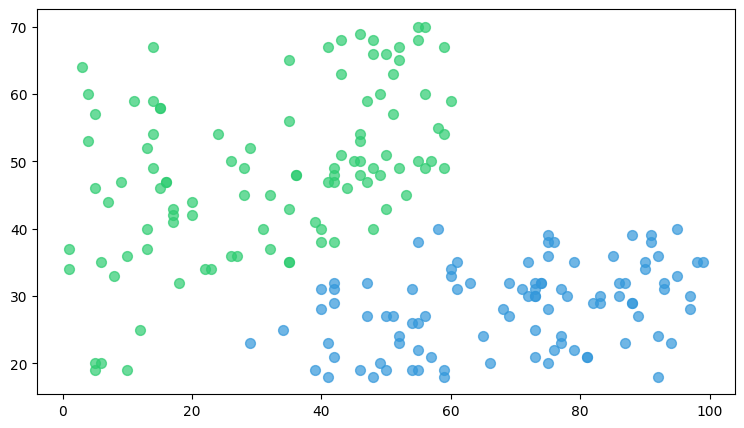

In [ ]:
#visualize clusters. - we note that the tie on cluster has female spenders
colours = ["#3498db",'#2ecc71' ] #'#f21cd1'
labels = ['High spenders', 'Low spenders']
 
plt.figure(figsize=(9, 5))
for c in range(2):
    mask = df['cluster'] == c
 
    plt.scatter(
        df[mask]['Spending Score (1-100)'],
        df[mask]['Annual Income (k$)'],
        c=colours[c], label= labels[c], alpha=0.7, s=50
)

cluster 2 = Highest spender
cluster 1 = mid spenders
cluster 0 = Average spenders
cluster 3 = Low spenders

In [ ]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, km_final.labels_)
print(score)

0.2518152915788437


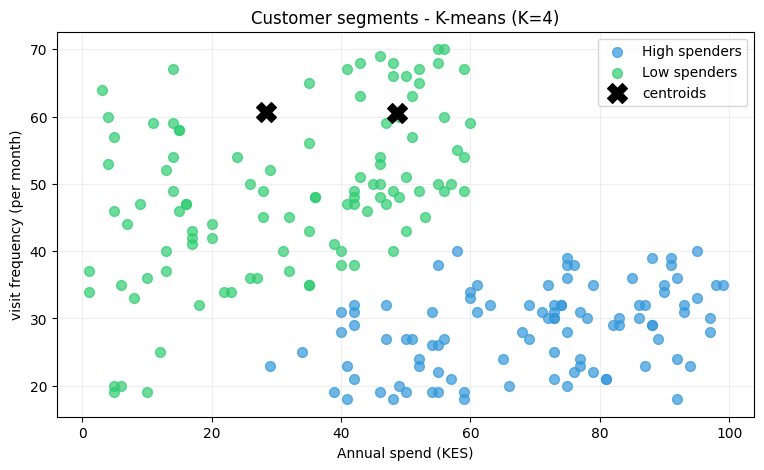

In [ ]:
# Plotting our centroids - the optimal position
#visualize clusters.
colours = ["#3498db",'#2ecc71' ] #'#f21cd1'
labels = ['High spenders', 'Low spenders']
 
plt.figure(figsize=(9, 5))
for c in range(2):
    mask = df['cluster'] == c
 
    plt.scatter(
        df[mask]['Spending Score (1-100)'],
        df[mask]['Annual Income (k$)'],
        c=colours[c], label= labels[c], alpha=0.7, s=50
    )    
centroids_orig = scaler.inverse_transform(km_final.cluster_centers_) # returns our feature before we scaled
plt.scatter(
    centroids_orig[:, 0],
    centroids_orig[:, 1],
    s=200, marker='X', c='black', zorder=5, label='centroids'
)

plt.xlabel('Annual spend (KES)')
plt.ylabel('visit frequency (per month)')
plt.title('Customer segments - K-means (K=4)')
plt.legend()
plt.grid(alpha=0.2)
plt.show()
